# Backpropagation for a general multilayer perceptron from scratch

This notebook shows how backpropagation appears in a realistic neural-network training setting.
Instead of hard-coding one specific architecture, we will write the code for a **general multilayer perceptron (MLP)** with an arbitrary number of layers and neurons.

We will:

- define an architecture through a list such as $[2, 8, 6, 3]$,
- implement the forward pass with loops,
- implement reverse-mode backpropagation layer by layer,
- validate the manual gradients with JAX,
- train the network on a small multiclass classification problem.

The hidden layers use $\tanh$ activations, and the output layer uses softmax.
For a mini-batch, the loss is the average cross-entropy

$$
\mathcal{L}=
-\frac{1}{m}\sum_{i=1}^m \sum_{k=1}^K y_{ik}\log p_{ik}.
$$


## Learning goals

By the end of the notebook you should be able to:

1. represent an MLP architecture with a list of layer sizes,
2. initialize the parameters of a general network,
3. implement the forward pass for an arbitrary number of layers,
4. implement reverse-mode backpropagation with a backward loop,
5. validate the manual gradients with JAX,
6. use the gradients to train a multiclass classifier from scratch.


## 1. Imports and a small synthetic dataset

We generate a small three-class dataset in $\mathbb{R}^2$.
The dataset is simple enough to visualize, but nonlinear enough to make the neural network useful.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

rng = np.random.default_rng(4)

centers = np.array([
    [-1.5, -0.5],
    [ 1.5,  0.0],
    [ 0.0,  1.8],
])

stds = [0.35, 0.40, 0.35]
points_per_class = 60

X_parts = []
y_parts = []

for class_id, (center, std) in enumerate(zip(centers, stds)):
    X_parts.append(rng.normal(loc=center, scale=std, size=(points_per_class, 2)))
    y_parts.append(np.full(points_per_class, class_id))

X = np.vstack(X_parts)
y = np.concatenate(y_parts)

perm = rng.permutation(len(X))
X = X[perm]
y = y[perm]

n_train = int(0.7 * len(X))
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

def one_hot(y, n_classes):
    Y = np.zeros((len(y), n_classes))
    Y[np.arange(len(y)), y] = 1.0
    return Y

Y_train = one_hot(y_train, 3)
Y_test = one_hot(y_test, 3)

print("Training set:", X_train.shape, Y_train.shape)
print("Test set:    ", X_test.shape, Y_test.shape)


Training set: (125, 2) (125, 3)
Test set:     (55, 2) (55, 3)


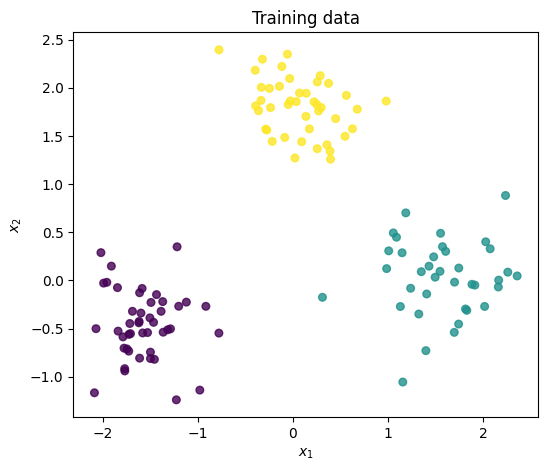

In [2]:
plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=30, alpha=0.8)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Training data")
plt.show()


## 2. Architecture and parameter initialization

Instead of fixing the network by hand, we encode the architecture with a list:

$$
[n_0, n_1, \dots, n_L].
$$

Here:

- $n_0$ is the input dimension,
- $n_1, \dots, n_{L-1}$ are the hidden-layer widths,
- $n_L$ is the output dimension.

For example, the list $[2, 8, 6, 3]$ means

$$
2 \longrightarrow 8 \longrightarrow 6 \longrightarrow 3.
$$

The code below should work for **any** architecture of this form.


In [ ]:
layer_dims = [2, 8, 6, 3]

def initialize_parameters(layer_dims, seed=0):
    rng = np.random.default_rng(seed)

    params = {"W": [], "b": []}

    for n_in, n_out in zip(layer_dims[:-1], layer_dims[1:]):
        # TODO: choose a scale for the random initialization
        # scale = ...

        # TODO: initialize one weight matrix and one bias vector
        # W = ...
        # b = ...

        params["W"].append(W)
        params["b"].append(b)

    return params

params = initialize_parameters(layer_dims, seed=2)

for ell, (W, b) in enumerate(zip(params["W"], params["b"]), start=1):
    print(f"Layer {ell}: W{ell} shape = {W.shape}, b{ell} shape = {b.shape}")


## 3. Forward propagation for a general MLP

For each layer $\ell = 1, \dots, L$, we compute

$$
Z^{(\ell)} = A^{(\ell-1)}W^{(\ell)} + b^{(\ell)}.
$$

For the hidden layers we then apply $\tanh$:

$$
A^{(\ell)} = \tanh\!\left(Z^{(\ell)}\right), \qquad \ell = 1, \dots, L-1.
$$

At the final layer we compute the class probabilities with softmax:

$$
P = \mathrm{softmax}\!\left(Z^{(L)}\right).
$$

The forward pass stores all intermediate activations and pre-activations, because reverse mode will need them later.


In [1]:
def softmax(logits):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_shifted = np.exp(shifted)
    return exp_shifted / exp_shifted.sum(axis=1, keepdims=True)

def cross_entropy(P, Y):
    return -np.mean(np.sum(Y * np.log(P + 1e-12), axis=1))


In [ ]:
def forward_pass(params, X, Y=None):
    A = X
    activations = [X]
    preactivations = []

    L = len(params["W"])

    for ell in range(L - 1):
        # TODO: compute the hidden-layer preactivation
        # Z = ...

        # TODO: apply the tanh activation
        # A = ...

        preactivations.append(Z)
        activations.append(A)

    # TODO: compute the output logits and probabilities
    # ZL = ...
    # P = ...

    preactivations.append(ZL)
    activations.append(P)

    cache = {
        "A": activations,
        "Z": preactivations,
        "P": P,
        "X": X,
    }

    if Y is not None:
        cache["Y"] = Y
        cache["loss"] = cross_entropy(P, Y)

    return cache

cache = forward_pass(params, X_train[:5], Y_train[:5])

for key, value in cache.items():
    if isinstance(value, float):
        print(f"{key:>4s} : {value:.6f}")
    elif isinstance(value, list):
        print(f"{key:>4s} : {[v.shape for v in value]}")
    else:
        print(f"{key:>4s} : shape {value.shape}")


### Quick check

If the architecture is $[2, 8, 6, 3]$, then:

- $W^{(1)}$ has shape $(2, 8)$,
- $W^{(2)}$ has shape $(8, 6)$,
- $W^{(3)}$ has shape $(6, 3)$,
- the output probabilities $P$ have shape $(m, 3)$ for a batch of size $m$.


## 4. Reverse-mode backpropagation for a general MLP

For the output layer with softmax and cross-entropy, the derivative simplifies to

$$
\delta^{(L)} = \frac{1}{m}(P - Y).
$$

Then we propagate backward through the layers.
For each layer $\ell = L, L-1, \dots, 1$,

$$
\frac{\partial \mathcal{L}}{\partial W^{(\ell)}} = \left(A^{(\ell-1)}\right)^\top \delta^{(\ell)},
\qquad
\frac{\partial \mathcal{L}}{\partial b^{(\ell)}} = \sum_{i=1}^m \delta_i^{(\ell)}.
$$

For hidden layers we also need

$$
\delta^{(\ell)}=
\left(\delta^{(\ell+1)}\left(W^{(\ell+1)}\right)^\top\right)
\odot
\left(1 - \left(A^{(\ell)}\right)^2\right).
$$

The important point is that the same formulas can be implemented with a loop, so the code does not depend on the number of layers.


In [ ]:
def backward_pass(params, cache):
    Y = cache["Y"]
    P = cache["P"]
    activations = cache["A"]

    L = len(params["W"])
    m = Y.shape[0]

    grads_W = [None] * L
    grads_b = [None] * L

    # TODO: output-layer error
    # dZ = ...

    for ell in reversed(range(L)):
        A_prev = activations[ell]

        # TODO: gradients for the parameters of layer ell
        # grads_W[ell] = ...
        # grads_b[ell] = ...

        if ell > 0:
            # TODO: propagate the error to the previous hidden layer
            # dA_prev = ...
            # H_prev = ...
            # dZ = ...

            pass

    grads = {"W": grads_W, "b": grads_b}
    return grads

cache = forward_pass(params, X_train, Y_train)
grads = backward_pass(params, cache)

print(f"Initial loss: {cache['loss']:.6f}")
for ell, (dW, db) in enumerate(zip(grads["W"], grads["b"]), start=1):
    print(f"Layer {ell}: ||dW|| = {np.linalg.norm(dW):.6f}, ||db|| = {np.linalg.norm(db):.6f}")


## 5. JAX validation

A strong sanity check is to compare the manual gradients with automatic differentiation.

We define the same general MLP loss in JAX and compare each manual gradient with the corresponding JAX gradient.


In [ ]:
import jax
import jax.numpy as jnp

def jax_softmax(logits):
    shifted = logits - jnp.max(logits, axis=1, keepdims=True)
    exp_shifted = jnp.exp(shifted)
    return exp_shifted / jnp.sum(exp_shifted, axis=1, keepdims=True)

def jax_loss(params, X, Y):
    A = X
    L = len(params["W"])

    for ell in range(L - 1):
        A = jnp.tanh(A @ params["W"][ell] + params["b"][ell])

    logits = A @ params["W"][-1] + params["b"][-1]
    P = jax_softmax(logits)

    return -jnp.mean(jnp.sum(Y * jnp.log(P + 1e-12), axis=1))

params_jax = {
    "W": [jnp.array(W) for W in params["W"]],
    "b": [jnp.array(b) for b in params["b"]],
}

# TODO: compute the JAX gradients
# jax_grads = ...

for ell in range(len(params["W"])):
    diff_W = np.max(np.abs(grads["W"][ell] - np.array(jax_grads["W"][ell])))
    diff_b = np.max(np.abs(grads["b"][ell] - np.array(jax_grads["b"][ell])))
    print(f"Layer {ell+1}: max |dW diff| = {diff_W:.3e}, max |db diff| = {diff_b:.3e}")


## 6. Training the network

Once the gradients are available, training is just repeated parameter updates.
We use plain gradient descent to keep the implementation transparent.


In [ ]:
def predict_proba(params, X):
    return forward_pass(params, X)["P"]

def predict(params, X):
    return np.argmax(predict_proba(params, X), axis=1)

def accuracy(params, X, y):
    return np.mean(predict(params, X) == y)

def train_network(params, X_train, Y_train, y_train, X_test, y_test, lr=0.2, epochs=600):
    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "test_acc": [],
    }

    for epoch in range(epochs):
        cache = forward_pass(params, X_train, Y_train)
        grads = backward_pass(params, cache)

        # TODO: gradient-descent update
        # for ell in range(len(params["W"])):
        #     ...

        if epoch % 20 == 0 or epoch == epochs - 1:
            history["epoch"].append(epoch)
            history["train_loss"].append(cache["loss"])
            history["train_acc"].append(accuracy(params, X_train, y_train))
            history["test_acc"].append(accuracy(params, X_test, y_test))

    return history, params

trained_params = initialize_parameters(layer_dims, seed=2)
history, trained_params = train_network(
    trained_params, X_train, Y_train, y_train, X_test, y_test,
    lr=0.2, epochs=600
)

print(f"Final training accuracy: {accuracy(trained_params, X_train, y_train):.3f}")
print(f"Final test accuracy:     {accuracy(trained_params, X_test, y_test):.3f}")


In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history["epoch"], history["train_loss"], marker="o")
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.title("Training loss during gradient descent")
plt.show()


In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history["epoch"], history["train_acc"], marker="o", label="train accuracy")
plt.plot(history["epoch"], history["test_acc"], marker="s", label="test accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy during training")
plt.legend()
plt.show()


## 7. Predictions and decision regions

Because the dataset is two-dimensional, we can visualize the decision regions learned by the network.


In [ ]:
x1_min, x1_max = X[:, 0].min() - 0.8, X[:, 0].max() + 0.8
x2_min, x2_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.8

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 250),
    np.linspace(x2_min, x2_max, 250),
)
X_grid = np.column_stack([xx1.ravel(), xx2.ravel()])

grid_pred = predict(trained_params, X_grid).reshape(xx1.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx1, xx2, grid_pred, alpha=0.25)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=25, alpha=0.85, label="train")
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, s=60, marker="x", label="test")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Decision regions after training")
plt.legend()
plt.show()


## 8. Discussion

1. Which parts of the code are truly independent of the number of layers?
2. Why does the backward pass run through the layers in reverse order?
3. Why is the output layer handled slightly differently from the hidden layers?
4. What is the role of the cache in the backward pass?
5. Why is it useful to compare the manual gradients with JAX?
